# AI Programming Foundations Project

## Project Introduction

**Name:** Stefan Gierl  
**Dataset:** Titanic - Machine Learning from Disaster  
**Project:** Reproducible Data Workflow with Python  

In this project, I analyze the Titanic dataset using Python, Pandas, NumPy, Matplotlib, and Seaborn. The goal is to build a complete and reproducible data workflow including data ingestion, data cleaning, exploratory data analysis, visualizations, and a short interpretation of the results.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
df = pd.read_csv("train.csv")

print("Dataset loaded successfully.")
print("Rows and columns:", df.shape)

df.head()

Dataset loaded successfully.
Rows and columns: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Basic dataset inspection

print("First 5 rows:")
display(df.head())

print("\nDataset information:")
df.info()

print("\nMissing values per column:")
missing_values = df.isnull().sum()
display(missing_values)

print("\nBasic statistics for numeric columns:")
display(df.describe())

print("\nColumn names:")
print(df.columns.tolist())

# Test line
print("\nTest successful: Dataset inspection completed.")

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

Missing values per column:


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


Basic statistics for numeric columns:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Column names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Test successful: Dataset inspection completed.


## Data Cleaning

In this section, I clean the Titanic dataset by handling missing values and creating additional useful variables for the analysis.

In [5]:
# Data Cleaning Functions

def clean_missing_values(data):
    """
    Cleans missing values in the Titanic dataset.
    
    - Missing Age values are replaced with the median age.
    - Missing Embarked values are replaced with the most common embarkation port.
    - The Cabin column is removed because it contains too many missing values.
    """
    cleaned_data = data.copy()
    
    cleaned_data["Age"] = cleaned_data["Age"].fillna(cleaned_data["Age"].median())
    cleaned_data["Embarked"] = cleaned_data["Embarked"].fillna(cleaned_data["Embarked"].mode()[0])
    
    if "Cabin" in cleaned_data.columns:
        cleaned_data = cleaned_data.drop(columns=["Cabin"])
    
    return cleaned_data


def create_family_features(data):
    """
    Creates additional family-related features.
    
    - FamilySize combines siblings/spouses and parents/children.
    - IsAlone marks passengers who travelled without family members.
    """
    cleaned_data = data.copy()
    
    cleaned_data["FamilySize"] = cleaned_data["SibSp"] + cleaned_data["Parch"] + 1
    cleaned_data["IsAlone"] = cleaned_data["FamilySize"].apply(lambda x: 1 if x == 1 else 0)
    
    return cleaned_data


# Apply cleaning functions
df_clean = clean_missing_values(df)
df_clean = create_family_features(df_clean)

# Display results
print("Cleaned dataset shape:", df_clean.shape)

print("\nMissing values after cleaning:")
display(df_clean.isnull().sum())

print("\nFirst 5 rows after cleaning:")
display(df_clean.head())

# Test line
assert df_clean.isnull().sum().sum() == 0
print("Test successful: Data cleaning completed and no missing values remain.")

Cleaned dataset shape: (891, 13)

Missing values after cleaning:


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
FamilySize     0
IsAlone        0
dtype: int64


First 5 rows after cleaning:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,1


Test successful: Data cleaning completed and no missing values remain.


## Exploratory Data Analysis

In this section, I explore the cleaned Titanic dataset. The goal is to understand important patterns in survival rates, passenger classes, gender, family size, and numeric relationships.

In [6]:
# Exploratory Data Analysis Function

def run_eda(data):
    """
    Performs exploratory data analysis on the cleaned Titanic dataset.
    
    The function shows:
    - Dataset shape
    - Column overview
    - Survival rate overall
    - Survival rate by sex
    - Survival rate by passenger class
    - Survival rate by embarkation port
    - Survival rate by travelling alone
    - Correlation matrix for numeric variables
    """
    print("Dataset shape:")
    print(data.shape)
    
    print("\nColumn overview:")
    display(data.dtypes)
    
    print("\nOverall survival rate:")
    overall_survival = data["Survived"].mean()
    print(round(overall_survival, 3))
    
    print("\nSurvival rate by sex:")
    survival_by_sex = data.groupby("Sex")["Survived"].mean().sort_values(ascending=False)
    display(survival_by_sex)
    
    print("\nSurvival rate by passenger class:")
    survival_by_class = data.groupby("Pclass")["Survived"].mean().sort_values(ascending=False)
    display(survival_by_class)
    
    print("\nSurvival rate by embarkation port:")
    survival_by_embarked = data.groupby("Embarked")["Survived"].mean().sort_values(ascending=False)
    display(survival_by_embarked)
    
    print("\nSurvival rate by travelling alone:")
    survival_by_alone = data.groupby("IsAlone")["Survived"].mean()
    display(survival_by_alone)
    
    print("\nCorrelation matrix for numeric columns:")
    numeric_data = data.select_dtypes(include=["int64", "float64"])
    correlation_matrix = numeric_data.corr()
    display(correlation_matrix)
    
    return {
        "overall_survival": overall_survival,
        "survival_by_sex": survival_by_sex,
        "survival_by_class": survival_by_class,
        "survival_by_embarked": survival_by_embarked,
        "survival_by_alone": survival_by_alone,
        "correlation_matrix": correlation_matrix
    }


# Run EDA
eda_results = run_eda(df_clean)

# Test line
assert "overall_survival" in eda_results
assert "correlation_matrix" in eda_results
print("\nTest successful: EDA function completed successfully.")

Dataset shape:
(891, 13)

Column overview:


PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Embarked           str
FamilySize       int64
IsAlone          int64
dtype: object


Overall survival rate:
0.384

Survival rate by sex:


Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


Survival rate by passenger class:


...


Survival rate by travelling alone:


IsAlone
0    0.505650
1    0.303538
Name: Survived, dtype: float64


Correlation matrix for numeric columns:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone
PassengerId,1.000000,-0.005007,-0.035144,0.034212,-0.057527,-0.001652,0.012658,-0.040143,0.057462
Survived,-0.005007,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307,0.016639,-0.203367
Pclass,-0.035144,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500,0.065997,0.135207
Age,0.034212,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688,-0.245619,0.171647
SibSp,-0.057527,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651,0.890712,-0.584471
Parch,-0.001652,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225,0.783111,-0.583398
Fare,0.012658,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000,0.217138,-0.271832
FamilySize,-0.040143,0.016639,0.065997,-0.245619,0.890712,0.783111,0.217138,1.000000,-0.690922
IsAlone,0.057462,-0.203367,0.135207,0.171647,-0.584471,-0.583398,-0.271832,-0.690922,1.000000



Test successful: EDA function completed successfully.


## Visualizations

This section includes three visualizations with titles, labeled axes, and short interpretations.

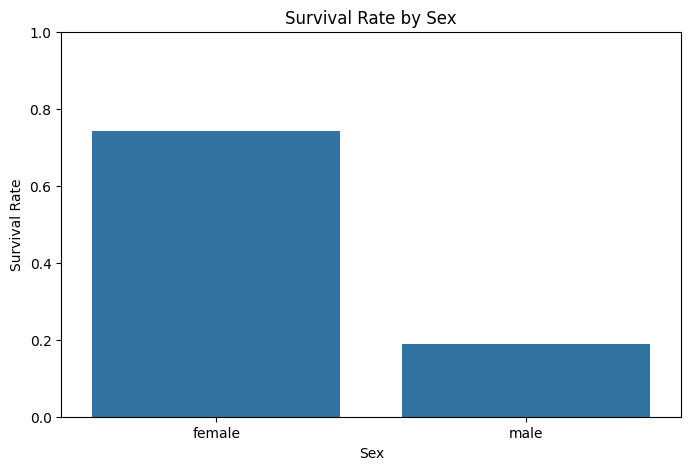

Interpretation 1:
Female passengers had a much higher survival rate than male passengers. This suggests that sex was an important factor in survival outcomes.



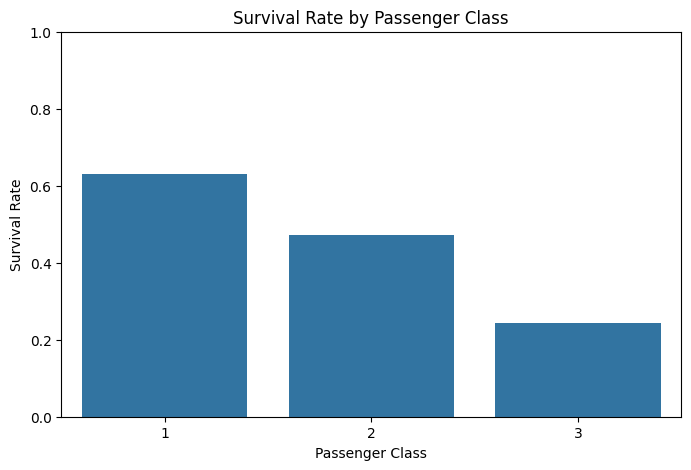

Interpretation 2:
Passengers in first class had the highest survival rate, while passengers in third class had the lowest survival rate. This suggests that passenger class was strongly related to survival.



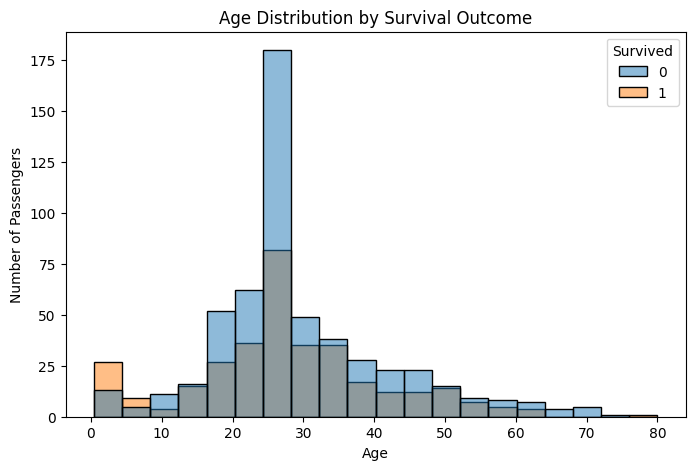

Interpretation 3:
The age distribution shows that passengers of many age groups were affected. Children and younger passengers appear in both survival groups, but survival was not determined by age alone.

Test successful: Three visualizations were created successfully.


In [7]:
# Visualizations

# Prepare grouped data
survival_by_sex_plot = df_clean.groupby("Sex")["Survived"].mean().reset_index()
survival_by_class_plot = df_clean.groupby("Pclass")["Survived"].mean().reset_index()
survival_by_alone_plot = df_clean.groupby("IsAlone")["Survived"].mean().reset_index()

# Visualization 1: Survival rate by sex
plt.figure(figsize=(8, 5))
sns.barplot(data=survival_by_sex_plot, x="Sex", y="Survived")
plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()

print("Interpretation 1:")
print("Female passengers had a much higher survival rate than male passengers. This suggests that sex was an important factor in survival outcomes.\n")


# Visualization 2: Survival rate by passenger class
plt.figure(figsize=(8, 5))
sns.barplot(data=survival_by_class_plot, x="Pclass", y="Survived")
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()

print("Interpretation 2:")
print("Passengers in first class had the highest survival rate, while passengers in third class had the lowest survival rate. This suggests that passenger class was strongly related to survival.\n")


# Visualization 3: Age distribution by survival outcome
plt.figure(figsize=(8, 5))
sns.histplot(data=df_clean, x="Age", hue="Survived", bins=20)
plt.title("Age Distribution by Survival Outcome")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

print("Interpretation 3:")
print("The age distribution shows that passengers of many age groups were affected. Children and younger passengers appear in both survival groups, but survival was not determined by age alone.\n")


# Test lines
assert len(survival_by_sex_plot) > 0
assert len(survival_by_class_plot) > 0
assert len(survival_by_alone_plot) > 0
print("Test successful: Three visualizations were created successfully.")

## Summary and Interpretation

The Titanic dataset shows clear patterns in passenger survival. The overall survival rate was about 38%, meaning that more passengers did not survive than survived.

One of the strongest patterns was the difference between female and male passengers. Female passengers had a much higher survival rate than male passengers. Passenger class was also important: first-class passengers had the highest survival rate, while third-class passengers had the lowest survival rate.

The age distribution showed that survival was not determined by age alone. Passengers from many age groups survived and did not survive. However, children and younger passengers appear as an important group to review more closely.

The dataset also has limitations. Some values were missing, especially in the Cabin column. Because Cabin had many missing values, it was removed during cleaning. Missing Age values were replaced with the median age, which keeps the dataset usable but may reduce some detail in the age distribution.

A possible source of bias is that the dataset only represents passengers included in this historical dataset. The results should not be interpreted as a complete explanation of every individual survival outcome. Instead, the analysis shows general patterns related to sex, passenger class, age, and family-related variables.

Overall, this project created a reproducible data workflow using Python. The workflow included data loading, inspection, cleaning, exploratory analysis, visualizations, and interpretation.

In [8]:
# Create requirements.txt file for reproducibility

!pip freeze > requirements.txt

# Test line
import os

if os.path.exists("requirements.txt"):
    print("Test successful: requirements.txt was created.")
else:
    print("Test failed: requirements.txt was not created.")

Test successful: requirements.txt was created.


In [10]:
# Create README.md file

readme_text = """# AI Programming Foundations Project

## Project Description

This project analyzes the Titanic dataset using a reproducible Python data workflow. The workflow includes data loading, data inspection, data cleaning, exploratory data analysis, visualizations, and a short interpretation of the results.

## Dataset

Dataset used: Titanic - Machine Learning from Disaster

Source: https://www.kaggle.com/c/titanic

The main dataset file used in this project is:

- train.csv

## What Was Built

This project includes:

- A Jupyter Notebook named data_workflow.ipynb
- Data loading with Pandas
- Data cleaning functions with docstrings
- Exploratory data analysis
- Three visualizations with interpretations
- A summary and interpretation section
- A requirements.txt file for reproducibility

## How to Install Dependencies

Run this command in the project folder:

pip install -r requirements.txt

## How to Run the Project

Start Jupyter Notebook with this command:

jupyter notebook

Then open:

data_workflow.ipynb

Run all cells from top to bottom.

## Reproducibility

The project can be reproduced by using the included requirements.txt file and running the notebook in order. The notebook is structured into clear sections for setup, data ingestion, cleaning, exploratory analysis, visualizations, and summary.

## Files Included

- data_workflow.ipynb
- README.md
- requirements.txt
- train.csv
- test.csv
- gender_submission.csv
"""

with open("README.md", "w", encoding="utf-8") as file:
    file.write(readme_text)

# Test line
import os

if os.path.exists("README.md"):
    print("Test successful: README.md was created.")
else:
    print("Test failed: README.md was not created.")

Test successful: README.md was created.


In [11]:
# Create module_summary.pdf

import os
import textwrap
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# Key values from the analysis
rows, columns = df.shape
clean_rows, clean_columns = df_clean.shape
overall_survival_rate = round(df_clean["Survived"].mean() * 100, 1)
female_survival_rate = round(df_clean[df_clean["Sex"] == "female"]["Survived"].mean() * 100, 1)
male_survival_rate = round(df_clean[df_clean["Sex"] == "male"]["Survived"].mean() * 100, 1)
first_class_survival_rate = round(df_clean[df_clean["Pclass"] == 1]["Survived"].mean() * 100, 1)
third_class_survival_rate = round(df_clean[df_clean["Pclass"] == 3]["Survived"].mean() * 100, 1)

report_text = f"""
AI Programming Foundations Project
Module Summary Report

Overview

This project built a reproducible data workflow using the Titanic dataset. The workflow includes data ingestion, data inspection, data cleaning, exploratory data analysis, visualizations, and interpretation. The main goal was not to train a machine learning model, but to create a structured and reusable foundation for later AI and data science work. This approach follows the idea that reproducible data science depends on clear workflows, documented decisions, and reusable code (Danchev, 2022).

Dataset Description

The dataset used in this project is the Titanic - Machine Learning from Disaster dataset. The main file analyzed was train.csv. The original dataset contained {rows} rows and {columns} columns. Important variables included Survived, Pclass, Sex, Age, SibSp, Parch, Fare, Cabin, and Embarked.

The target variable was Survived, where 0 means the passenger did not survive and 1 means the passenger survived. Passenger class, sex, age, family size, and travel status were used to explore survival patterns. The dataset contained missing values, especially in the Cabin column and some missing values in Age and Embarked.

Workflow Description

The workflow started by importing NumPy, Pandas, Matplotlib, and Seaborn. The Titanic dataset was then loaded with Pandas and inspected using head(), info(), describe(), and missing value checks. Pandas was appropriate for this task because it provides data structures designed for practical statistical data work in Python (McKinney, 2010).

After inspection, the data was cleaned using two custom functions with docstrings. The first function handled missing values. Missing Age values were replaced with the median age, missing Embarked values were replaced with the most common embarkation port, and Cabin was removed because it had too many missing values. The second function created two new variables: FamilySize and IsAlone.

Exploratory data analysis was then performed using a custom EDA function. The function calculated the overall survival rate, survival by sex, survival by passenger class, survival by embarkation port, survival by travelling alone, and a correlation matrix for numeric variables.

Key Decisions and Assumptions

A key decision was to remove the Cabin column because it contained many missing values. Keeping this column would have added limited value to the analysis and could have introduced misleading assumptions. Another decision was to replace missing Age values with the median age. This preserved the dataset size while reducing the influence of extreme age values.

A further decision was to create FamilySize and IsAlone. These features made the dataset easier to analyze because SibSp and Parch separately describe family relationships, while FamilySize gives a clearer combined measure. The workflow was kept simple and reproducible so that another person can rerun the notebook from top to bottom.

Results and Interpretation

The overall survival rate was approximately {overall_survival_rate} percent. This means that most passengers in the dataset did not survive.

One of the strongest patterns was the difference between female and male passengers. Female passengers had a survival rate of approximately {female_survival_rate} percent, while male passengers had a survival rate of approximately {male_survival_rate} percent. This suggests that sex was strongly related to survival outcomes in this dataset.

Passenger class was also important. First-class passengers had a survival rate of approximately {first_class_survival_rate} percent, while third-class passengers had a survival rate of approximately {third_class_survival_rate} percent. This suggests that passenger class was related to survival probability.

The age distribution showed that survival was not explained by age alone. Passengers from many age groups both survived and did not survive. Therefore, age should be interpreted together with other variables such as sex and passenger class.

Responsible Practice: Bias and Data Quality

The dataset has important limitations. Missing values can affect the analysis, especially if the missing data is not random. Removing Cabin was reasonable because the column had too many missing values, but this also means that possible information about passenger location on the ship was not analyzed.

Replacing missing Age values with the median age made the dataset easier to use, but it may reduce detail in the age distribution. This is a common tradeoff in data cleaning: the dataset becomes complete, but some original variation may be lost.

The analysis should not be interpreted as a complete explanation of every individual survival outcome. It shows general patterns in the available dataset. Historical context, emergency procedures, passenger location, and other factors are not fully captured in this dataset.

Reproducibility

The project supports reproducibility by using a clear notebook structure, reusable functions, documented cleaning decisions, and a requirements.txt file. The notebook can be rerun from top to bottom. The GitHub repository should include multiple commits and at least one additional branch to document development progress.

The README.md file explains how to install dependencies and how to run the notebook. These steps make the project easier for another person to reproduce. Reproducibility is important because data science results should be understandable, repeatable, and verifiable (Danchev, 2022).

Sources and Citations

The workflow used Pandas for data handling and Matplotlib/Seaborn for visualization. Matplotlib is a widely used Python library for creating publication-quality visualizations (Hunter, 2007). In this project, visualizations were used to communicate survival patterns clearly.

References

Danchev, V. (2022). Reproducible Data Science with Python: An Open Learning Resource. Journal of Open Source Education, 5(56), 156. https://doi.org/10.21105/jose.00156

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. Computing in Science & Engineering, 9(3), 90-95. https://doi.org/10.1109/MCSE.2007.55

McKinney, W. (2010). Data Structures for Statistical Computing in Python. Proceedings of the 9th Python in Science Conference, 56-61. https://doi.org/10.25080/Majora-92bf1922-00a
"""

def add_text_page(pdf, text, title=None):
    """
    Adds wrapped text pages to a PDF using Matplotlib.
    """
    lines = []
    for paragraph in text.strip().split("\n"):
        if paragraph.strip() == "":
            lines.append("")
        else:
            wrapped = textwrap.wrap(paragraph, width=95)
            lines.extend(wrapped)
    
    lines_per_page = 42
    for start in range(0, len(lines), lines_per_page):
        page_lines = lines[start:start + lines_per_page]
        fig = plt.figure(figsize=(8.27, 11.69))  # A4 size
        plt.axis("off")
        
        y_position = 0.96
        for line in page_lines:
            fig.text(0.08, y_position, line, fontsize=10, va="top")
            y_position -= 0.022
        
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

# Create PDF
pdf_filename = "module_summary.pdf"

with PdfPages(pdf_filename) as pdf:
    add_text_page(pdf, report_text)

# Test line
if os.path.exists(pdf_filename):
    print("Test successful: module_summary.pdf was created.")
else:
    print("Test failed: module_summary.pdf was not created.")

Test successful: module_summary.pdf was created.


In [14]:
# Final project file check

import os

required_files = [
    "data_workflow.ipynb",
    "module_summary.pdf",
    "requirements.txt",
    "README.md",
    "train.csv",
    "test.csv",
    "gender_submission.csv"
]

print("Project file check:\n")

all_files_available = True

for file in required_files:
    if os.path.exists(file):
        print(f"OK: {file}")
    else:
        print(f"Missing: {file}")
        all_files_available = False

# Test line
if all_files_available:
    print("\nTest successful: All required project files are available.")
else:
    print("\nTest failed: Some required files are missing.")

Project file check:

OK: data_workflow.ipynb
OK: module_summary.pdf
OK: requirements.txt
OK: README.md
OK: train.csv
OK: test.csv
OK: gender_submission.csv

Test successful: All required project files are available.
